Load Dataset

In [77]:
import pandas as pd
import numpy as np

df = pd.read_csv("Netflix.csv", encoding="latin-1")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Understanding Data

In [78]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null    

Drop Unnecessary Columns

In [79]:
# Drop empty unnamed columns
df = df.loc[:, ~df.columns.str.contains('Unnamed')]
df.shape

(8809, 12)

In [80]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Check Missing Values

In [81]:
df.isna().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


Handling Missing Values

In [82]:
df_clean = df.copy()

# Parse dates
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

# Feature engineering
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['duration_num'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)
df_clean['main_genre'] = df_clean['listed_in'].str.split(',').str[0]
df_clean['main_country'] = df_clean['country'].fillna('Unknown').str.split(',').str[0]

# Handle missing values
for col in ['director', 'cast', 'country', 'rating', 'duration']:
    df_clean[col] = df_clean[col].fillna('Unknown')

df_clean.isna().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


Checking Duplicate Values

In [83]:
print("Total rows:", len(df_clean))
print("Exact Duplicate rows:", df_clean.duplicated().sum())
print("Logical Duplicate rows:", df_clean.duplicated(subset=['title'], keep=False).sum())

Total rows: 8809
Exact Duplicate rows: 0
Logical Duplicate rows: 6


In [84]:
df_clean[df_clean.duplicated(subset=['title'], keep=False)].sort_values('title')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_num,main_genre,main_country
3962,s3963,Movie,15-Aug,Swapnaneel Jayakar,"Rahul Pethe, Mrunmayee Deshpande, Adinath Koth...",India,2019-03-29,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies","On India's Independence Day, a zany mishap in ...",2019.0,124.0,Comedies,India
5966,s5967,Movie,15-Aug,Swapnaneel Jayakar,"Rahul Pethe, Mrunmayee Deshpande, Adinath Koth...",India,2019-03-29,2019,TV-14,124 min,"Comedies, Dramas, Independent Movies","On India's Independence Day, a zany mishap in ...",2019.0,124.0,Comedies,India
4522,s4523,Movie,22-Jul,Paul Greengrass,"Anders Danielsen Lie, Jon Ãigarden, Jonas Str...","Norway, Iceland, United States",2018-10-10,2018,R,144 min,"Dramas, Thrillers","After devastating terror attacks in Norway, a ...",2018.0,144.0,Dramas,Norway
5965,s5966,Movie,22-Jul,Paul Greengrass,"Anders Danielsen Lie, Jon Ãigarden, Jonas Str...","Norway, Iceland, United States",2018-10-10,2018,R,144 min,"Dramas, Thrillers","After devastating terror attacks in Norway, a ...",2018.0,144.0,Dramas,Norway
3996,s3997,TV Show,Feb-09,Unknown,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",Unknown,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h...",2019.0,1.0,International TV Shows,Unknown
5964,s5965,TV Show,Feb-09,Unknown,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",Unknown,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h...",2019.0,1.0,International TV Shows,Unknown


Handling Duplicate Values

In [85]:
df_clean = df_clean.drop_duplicates(subset=['title'], keep='first')

In [86]:
print("Logical Duplicate rows:", df_clean.duplicated(subset=['title'], keep=False).sum())

Logical Duplicate rows: 0


In [87]:
df_clean.shape

(8806, 16)

EDA

Movies vs TV Shows

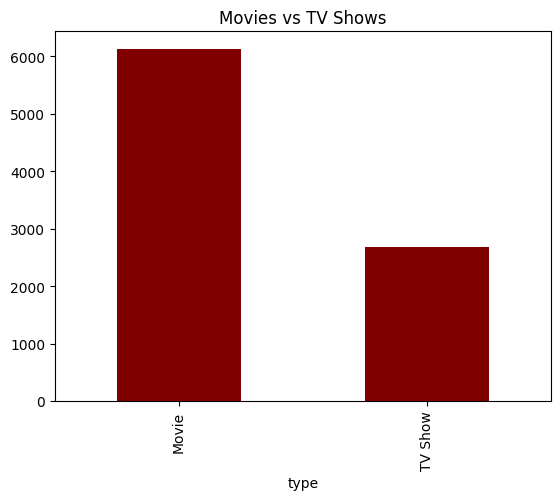

In [88]:
import matplotlib.pyplot as plt

df_clean['type'].value_counts().plot(kind='bar', title='Movies vs TV Shows', color='maroon')
plt.show()


Movies dominate the catalog (approx. 70%), but TV shows form a significant share (approx. 30%), indicating Netflix’s strong investment in series-driven user retention.

Content Growth Over Time

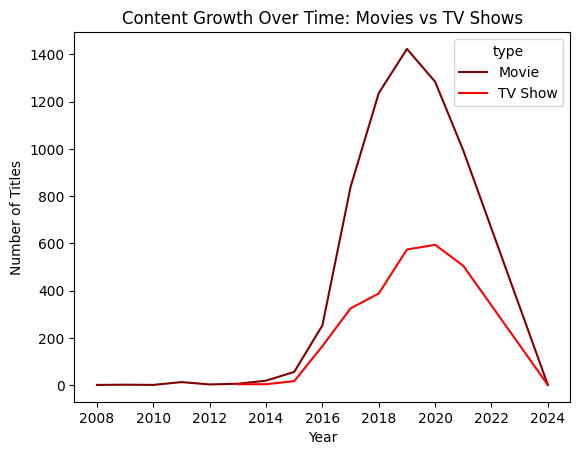

In [89]:
(df_clean[df_clean['year_added'].notna()]
 .groupby(['year_added','type']).size().unstack().plot(kind='line', title='Content Growth Over Time: Movies vs TV Shows', color=['maroon','red']))

plt.xlabel("Year"); plt.ylabel("Number of Titles"); plt.show()

Rapid growth after 2016 suggests aggressive content expansion as Netflix scaled globally.

Top Producing Countries

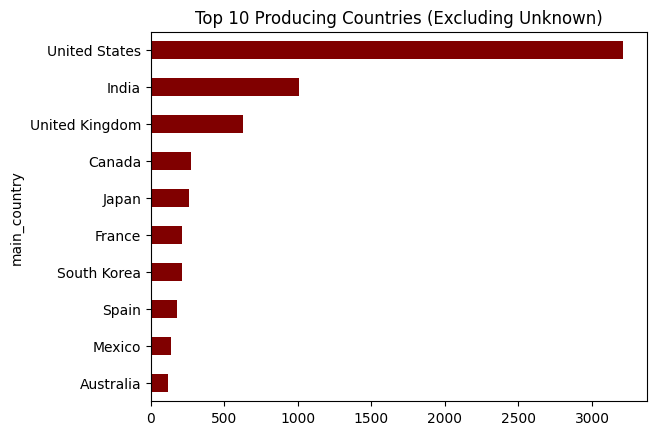

In [90]:
(df_clean[df_clean['main_country'] != 'Unknown']['main_country']
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind='barh', title='Top 10 Producing Countries (Excluding Unknown)', color='maroon'))
plt.show()


The US leads content production, but international markets contribute significantly to the catalog.

Top Genres

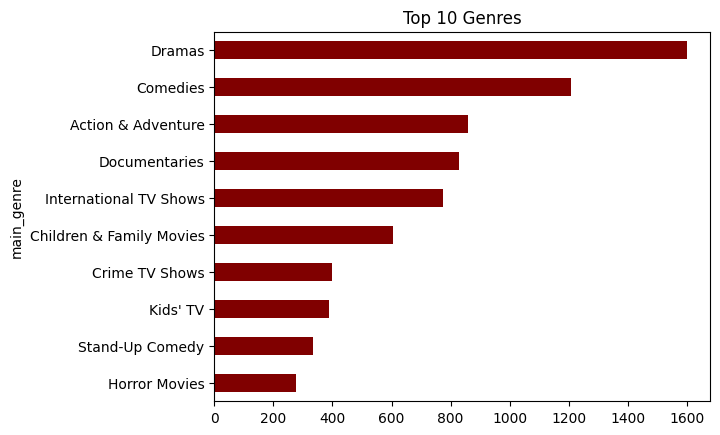

In [91]:
df_clean['main_genre'].value_counts().head(10).sort_values().plot(kind='barh', color='maroon', title='Top 10 Genres')
plt.show()


Drama dominates Netflix’s catalog, followed by international content and comedies.

Ratings Distribution

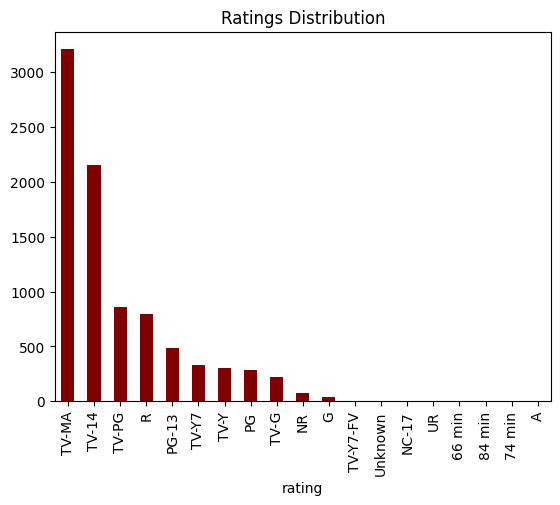

In [92]:
df_clean['rating'].value_counts().sort_values(ascending=False).plot(kind='bar', color='maroon', title='Ratings Distribution')
plt.show()


Netflix’s catalog skews toward mature content (TV-MA), reflecting adult audience targeting.

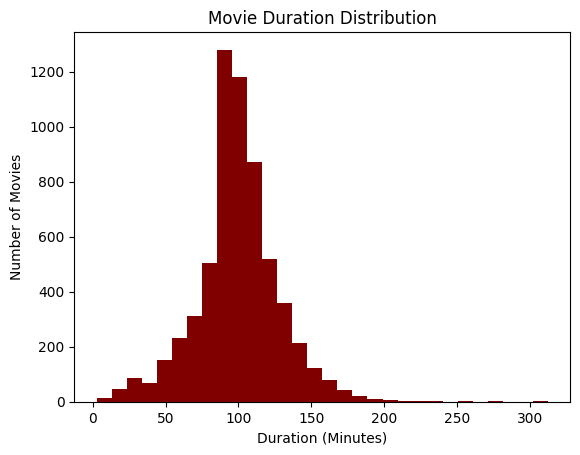

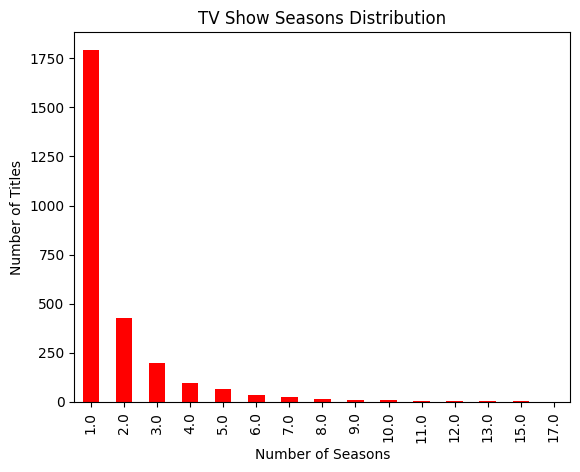

In [93]:
# Movie duration distribution
(df_clean[df_clean['type'] == 'Movie']
 .dropna(subset=['duration_num'])
 ['duration_num']
 .plot(kind='hist', bins=30, color='maroon', title='Movie Duration Distribution'))

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()


# TV Show seasons distribution
# Filter TV Shows and remove null duration values
tv_df = df_clean[df_clean['type'] == 'TV Show'].dropna(subset=['duration_num'])

# Plot distribution of number of seasons
(tv_df['duration_num']
 .value_counts()
 .sort_index()
 .plot(
     kind='bar',
     color='red',
     title='TV Show Seasons Distribution'
 ))

# Labels
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Titles")

plt.show()

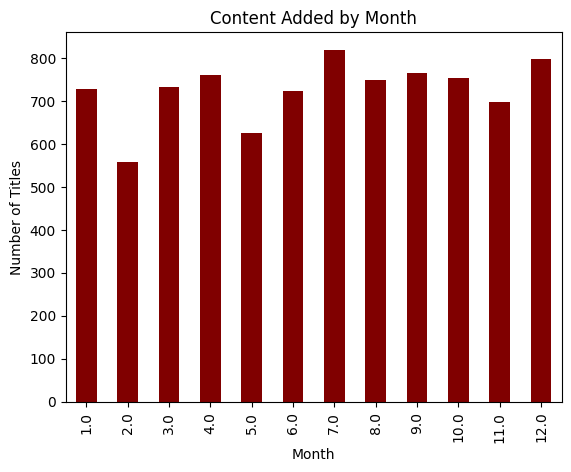

In [94]:
df_clean['month_added'] = df_clean['date_added'].dt.month

df_clean['month_added'].value_counts().sort_index().plot(
    kind='bar', title='Content Added by Month', color='maroon'
)

plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

Netflix content additions are fairly consistent throughout the year, with a peak around July and December, suggesting strategic releases during mid-year and holiday seasons. There’s a slight dip in early months like February, indicating slower content rollout periods.

Save Cleaned Dataset

In [95]:
df_clean.to_csv("Netflix_Cleaned_Dataset.csv", index=False)

In [96]:
df_clean.to_excel("Netflix_Cleaned_Dataset.xlsx", index=False)